In [2]:
!pip install pandas numpy lightgbm shap matplotlib seaborn plotly prophet statsmodels -q 

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Import thành công")

data_path = r"C:\DATATHON ROUND1"
folder = Path(data_path)

files = {
        'products.csv': {},
        'customers.csv': {'parse_dates': ['signup_date']},
        'promotions.csv': {'parse_dates': ['start_date', 'end_date']},
        'geography.csv': {},
        'orders.csv': {'parse_dates': ['order_date']},
        'order_items.csv': {},
        'payments.csv': {},
        'shipments.csv': {'parse_dates': ['ship_date', 'delivery_date']},
        'returns.csv': {'parse_dates': ['return_date']},
        'reviews.csv': {'parse_dates': ['review_date']},
        'sales.csv': {'parse_dates': ['Date']},
        'sample_submission.csv': {'parse_dates': ['Date']},
        'inventory.csv': {'parse_dates': ['snapshot_date']},
        'web_traffic.csv': {'parse_dates': ['date']},
}

data = {}
for filename, kwargs in files.items():
    df = pd.read_csv(folder / filename, **kwargs)
    data[filename.replace('.csv', '')] = df
    print(f" {filename:<20} | Shape: {df.shape}")

Import thành công
 products.csv         | Shape: (2412, 8)
 customers.csv        | Shape: (121930, 7)
 promotions.csv       | Shape: (50, 10)
 geography.csv        | Shape: (39948, 4)
 orders.csv           | Shape: (646945, 8)
 order_items.csv      | Shape: (714669, 7)
 payments.csv         | Shape: (646945, 4)
 shipments.csv        | Shape: (566067, 4)
 returns.csv          | Shape: (39939, 7)
 reviews.csv          | Shape: (113551, 7)
 sales.csv            | Shape: (3833, 3)
 sample_submission.csv | Shape: (548, 3)
 inventory.csv        | Shape: (60247, 17)
 web_traffic.csv      | Shape: (3652, 7)


In [3]:
# 1. Chuẩn bị dữ liệu: Kết nối Orders và Order_Items để tính tiền
# Lưu ý: Chúng ta lấy (quantity * unit_price) - discount_amount để ra số tiền thực tế
order_details = pd.merge(
    data['orders'][['order_id', 'customer_id', 'order_date']], 
    data['order_items'][['order_id', 'quantity', 'unit_price', 'discount_amount']], 
    on='order_id'
)

# Tính tổng tiền cho mỗi dòng sản phẩm trong đơn hàng
order_details['total_price'] = (order_details['quantity'] * order_details['unit_price']) - order_details['discount_amount']

# 2. Xác định ngày phân tích (Snapshot Date) 
# Thường là ngày sau ngày đặt hàng cuối cùng trong dữ liệu 1 ngày
snapshot_date = order_details['order_date'].max() + pd.Timedelta(days=1)

# 3. Tính toán R, F, M cho từng khách hàng
rfm = order_details.groupby('customer_id').agg({
    'order_date': lambda x: (snapshot_date - x.max()).days, # Recency: Số ngày kể từ lần mua cuối
    'order_id': 'nunique',                                 # Frequency: Số đơn hàng duy nhất
    'total_price': 'sum'                                   # Monetary: Tổng số tiền đã chi
})

# Đổi tên cột cho dễ nhìn
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# 4. Đánh điểm từ 1-5 bằng phương pháp Chia phân vị (Quantiles)
# Với Recency: Càng nhỏ càng tốt (mới mua) -> score cao
# Với Frequency & Monetary: Càng lớn càng tốt -> score cao
rfm["R_score"] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])
rfm["F_score"] = pd.qcut(rfm['Frequency'].rank(method="first"), 5, labels=[1, 2, 3, 4, 5])
rfm["M_score"] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

# 5. Kết hợp thành chuỗi RFM Score và Tổng điểm
rfm['RFM_Segment'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)
rfm['RFM_Score'] = rfm[['R_score', 'F_score', 'M_score']].sum(axis=1)

# 6. Phân nhóm khách hàng (Customer Segmentation)
# Đây là bảng quy đổi thông dụng để bạn viết insight trong Part 2
segs = {
    r'[1-2][1-2]': 'Hibernating',
    r'[1-2][3-4]': 'At Risk',
    r'[1-2]5': 'Can\'t Loose Them',
    r'3[1-2]': 'About To Sleep',
    r'33': 'Need Attention',
    r'[3-4][4-5]': 'Loyal Customers',
    r'41': 'Promising',
    r'51': 'New Customers',
    r'[4-5][2-3]': 'Potential Loyalists',
    r'5[4-5]': 'Champions'
}

# Chúng ta dùng cột R và F để phân nhóm chính (quy ước ngành Retail)
rfm['Segment'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str)
rfm['Segment'] = rfm['Segment'].replace(segs, regex=True)

print("Tính toán RFM hoàn tất!")
rfm.head()

Tính toán RFM hoàn tất!


,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Segment,RFM_Score,Segment
customer_id,,,,,,,,,
1,617,6,142803.47,4,4,4,444,12,Loyal Customers
2,179,4,204693.89,5,3,4,534,12,Potential Loyalists
3,3443,3,52093.47,1,2,2,122,5,Hibernating
4,917,1,10939.06,3,1,1,311,5,About To Sleep
5,1376,5,64179.86,3,3,3,333,9,Need Attention


Tỉ lệ trả hàng theo từng loại mặt hàng:


,category,total_sold,total_returned,return_rate_pct
1,GenZ,166848.0,5869.0,3.517573
2,Outdoor,1170000.0,40417.0,3.454444
3,Streetwear,1768826.0,59801.0,3.380830
0,Casual,107469.0,3499.0,3.255823


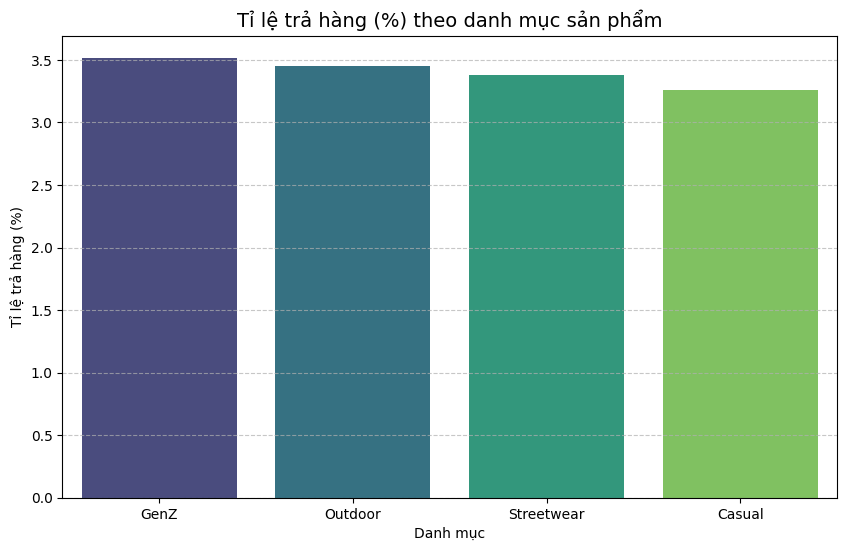

In [4]:
# 1. Tính tổng số lượng bán ra của từng sản phẩm (từ bảng order_items)
sold_units = data['order_items'].groupby('product_id')['quantity'].sum().reset_index()
sold_units.columns = ['product_id', 'total_sold']

# 2. Tính tổng số lượng bị trả lại của từng sản phẩm (từ bảng returns)
returned_units = data['returns'].groupby('product_id')['return_quantity'].sum().reset_index()
returned_units.columns = ['product_id', 'total_returned']

# 3. Kết nối với bảng products để lấy thông tin Category
product_info = data['products'][['product_id', 'category']]

# Kết hợp tất cả lại
df_return_rate = pd.merge(product_info, sold_units, on='product_id', how='left')
df_return_rate = pd.merge(df_return_rate, returned_units, on='product_id', how='left')

# Thay thế các giá trị NaN (không có lượt bán hoặc không bị trả) bằng 0
df_return_rate = df_return_rate.fillna(0)

# 4. Gom nhóm theo Category để tính tỉ lệ tổng quát
category_analysis = df_return_rate.groupby('category').agg({
    'total_sold': 'sum',
    'total_returned': 'sum'
}).reset_index()

# Tính % tỉ lệ trả hàng
category_analysis['return_rate_pct'] = (category_analysis['total_returned'] / category_analysis['total_sold']) * 100

# Sắp xếp theo tỉ lệ trả hàng giảm dần
category_analysis = category_analysis.sort_values('return_rate_pct', ascending=False)

print("Tỉ lệ trả hàng theo từng loại mặt hàng:")
display(category_analysis)

# 5. Trực quan hóa
plt.figure(figsize=(10, 6))
sns.barplot(data=category_analysis, x='category', y='return_rate_pct', palette='viridis')
plt.title('Tỉ lệ trả hàng (%) theo danh mục sản phẩm', fontsize=14)
plt.ylabel('Tỉ lệ trả hàng (%)')
plt.xlabel('Danh mục')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [5]:
# 1. Lọc các đơn hàng có trạng thái 'shipped'
shipped_orders = data['orders'][data['orders']['order_status'] == 'shipped'][['order_id', 'order_status']]

# 2. Kết nối với bảng shipments để lấy ngày xuất kho (ship_date)
shipped_with_dates = pd.merge(shipped_orders, data['shipments'][['order_id', 'ship_date']], on='order_id', how='inner')

# 3. Kết nối với order_items và products để biết chính xác là món hàng nào
shipped_details = pd.merge(shipped_with_dates, data['order_items'][['order_id', 'product_id']], on='order_id')
shipped_final = pd.merge(shipped_details, data['products'][['product_id', 'product_name']], on='product_id')

# 4. Thiết lập ngày hiện tại là 01/01/2023
current_date = pd.to_datetime('2023-01-01')

# 5. Tính số ngày đã trôi qua kể từ khi xuất kho
shipped_final['days_since_shipped'] = (current_date - shipped_final['ship_date']).dt.days

# Sắp xếp để xem những món bị kẹt lâu nhất
shipped_final = shipped_final.sort_values('days_since_shipped', ascending=False)

print(f"Tổng số lượng sản phẩm đang ở trạng thái 'shipped': {len(shipped_final)}")
display(shipped_final[['order_id', 'product_name', 'ship_date', 'days_since_shipped']].head(10))

Tổng số lượng sản phẩm đang ở trạng thái 'shipped': 15082


,order_id,product_name,ship_date,days_since_shipped
6,472,UrbanVN UE-13,2012-07-06,3831
1,157,SaigonFlex UC-12,2012-07-07,3830
2,164,MekongFit UR-05,2012-07-07,3830
7,492,PhoenixWear UR-04,2012-07-07,3830
0,15,SaigonFlex UC-39,2012-07-07,3830
5,425,SaigonFlex UE-20,2012-07-08,3829
4,416,SaigonFlex UM-80,2012-07-09,3828
11,870,HanoiStreet UC-52,2012-07-09,3828
15,935,MekongFit UE-22,2012-07-09,3828
3,237,MekongFit UE-22,2012-07-10,3827


In [6]:
import pandas as pd

# 1. Chuyển đổi định dạng ngày tháng
orders = data['orders'].copy()
customers = data['customers'].copy()
shipments = data['shipments'].copy()
payments = data['payments'].copy()

orders['order_date'] = pd.to_datetime(orders['order_date'])
customers['signup_date'] = pd.to_datetime(customers['signup_date'])
shipments['ship_date'] = pd.to_datetime(shipments['ship_date'])
current_date = pd.to_datetime('2023-01-01')

# --- THỐNG KÊ 1: Đơn hàng trước ngày đăng ký ---
order_cust = pd.merge(orders[['order_id', 'customer_id', 'order_date']], 
                      customers[['customer_id', 'signup_date']], on='customer_id')
anomalous_orders = order_cust[order_cust['order_date'] < order_cust['signup_date']]

print(f"1. Số lượng đơn hàng tạo trước khi khách đăng ký: {len(anomalous_orders)}")
print(f"   Số lượng khách hàng bị lỗi này: {anomalous_orders['customer_id'].nunique()}")


# --- THỐNG KÊ 4: Trả góp và tình trạng thanh toán ---
inst_types = [2, 3, 6, 12]
installment_data = payments[payments['installments'].isin(inst_types)]
inst_counts = installment_data['installments'].value_counts().sort_index()

# Giả định: Đơn 'paid' hoặc 'delivered' là đã trả hết
inst_status = pd.merge(installment_data, orders[['order_id', 'order_status']], on='order_id')
fully_paid = inst_status[inst_status['order_status'].isin(['paid', 'delivered'])]

print("\n4. Thống kê trả góp:")
for count, val in inst_counts.items():
    print(f"   - Loại {count} lần: {val} đơn")
print(f"   => Tổng số đơn trả góp (2,3,6,12 lần): {len(inst_status)}")
print(f"   => Số đơn đã trả hết (Trạng thái Paid/Delivered): {len(fully_paid)}")

1. Số lượng đơn hàng tạo trước khi khách đăng ký: 477453
   Số lượng khách hàng bị lỗi này: 80623

4. Thống kê trả góp:
   - Loại 2 lần: 1094 đơn
   - Loại 3 lần: 218949 đơn
   - Loại 6 lần: 109910 đơn
   - Loại 12 lần: 54126 đơn
   => Tổng số đơn trả góp (2,3,6,12 lần): 384079
   => Số đơn đã trả hết (Trạng thái Paid/Delivered): 321623


In [7]:
# Tạo bảng master orders bằng cách merge các bảng liên quan
df_orders_full = data['orders'].merge(data['customers'], on='customer_id', how='left', suffixes=('', '_cust'))
df_orders_full = df_orders_full.merge(data['geography'], on='zip', how='left')

# Tạo bảng chi tiết sản phẩm trong đơn hàng
df_items_full = data['order_items'].merge(data['products'], on='product_id', how='left')
df_items_full = df_items_full.merge(df_orders_full, on='order_id', how='left')

# Thêm thông tin trả hàng để phân tích rủi ro
df_items_full = df_items_full.merge(data['returns'], on=['order_id', 'product_id'], how='left')
df_items_full['is_returned'] = df_items_full['return_id'].notnull()

print("Bảng df_items_full đã sẵn sàng với shape:", df_items_full.shape)

Bảng df_items_full đã sẵn sàng với shape: (714673, 36)


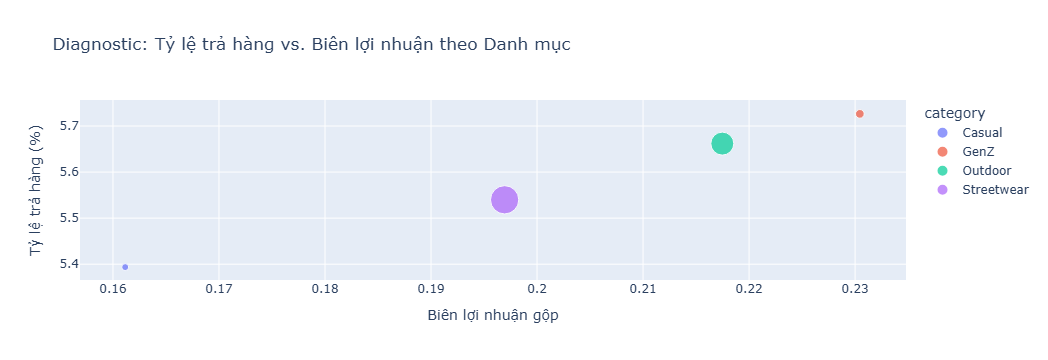

In [8]:
import plotly.express as px

# Tính tỷ lệ trả hàng và lợi nhuận gộp theo danh mục
cat_analysis = df_items_full.groupby('category').agg({
    'order_id': 'count',
    'is_returned': 'sum',
    'price': 'mean',
    'cogs': 'mean'
}).reset_index()

cat_analysis['return_rate'] = (cat_analysis['is_returned'] / cat_analysis['order_id']) * 100
cat_analysis['gross_margin'] = (cat_analysis['price'] - cat_analysis['cogs']) / cat_analysis['price']

# Trực quan hóa mối quan hệ giữa Lợi nhuận và Tỷ lệ trả hàng
fig = px.scatter(cat_analysis, x='gross_margin', y='return_rate', 
                 size='order_id', color='category', hover_name='category',
                 title='Diagnostic: Tỷ lệ trả hàng vs. Biên lợi nhuận theo Danh mục',
                 labels={'gross_margin': 'Biên lợi nhuận gộp', 'return_rate': 'Tỷ lệ trả hàng (%)'})
fig.show()

# Insight gợi ý: Nếu Streetwear có tỷ lệ trả hàng cao do 'wrong_size', 
# đề xuất hành động là cải thiện bảng size chart trên web[cite: 153, 155].

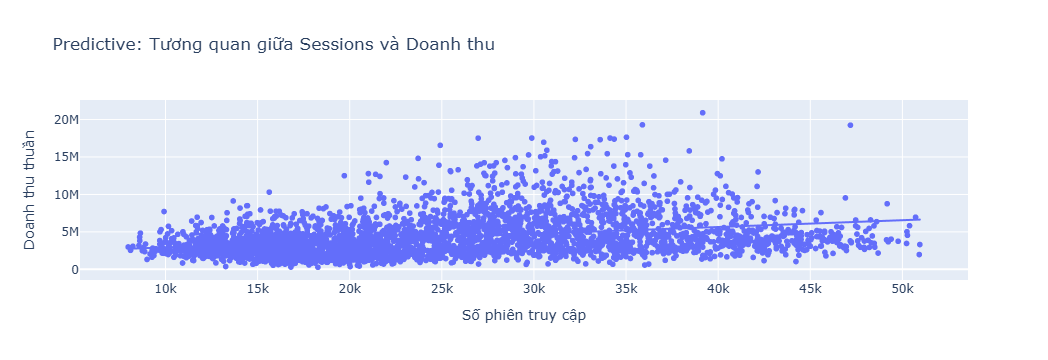

Hệ số tương quan Pearson: 0.32


In [9]:
# Gom nhóm doanh thu theo ngày và merge với traffic
daily_sales = data['sales'].groupby('Date')['Revenue'].sum().reset_index()
daily_traffic = data['web_traffic'].groupby('date')['sessions'].sum().reset_index()

df_predictive = daily_sales.merge(daily_traffic, left_on='Date', right_on='date')

# Vẽ biểu đồ tương quan có đường xu hướng
fig2 = px.scatter(df_predictive, x='sessions', y='Revenue', trendline="ols",
                  title='Predictive: Tương quan giữa Sessions và Doanh thu',
                  labels={'sessions': 'Số phiên truy cập', 'Revenue': 'Doanh thu thuần'})
fig2.show()

# Tính hệ số tương quan
correlation = df_predictive['sessions'].corr(df_predictive['Revenue'])
print(f"Hệ số tương quan Pearson: {correlation:.2f}")

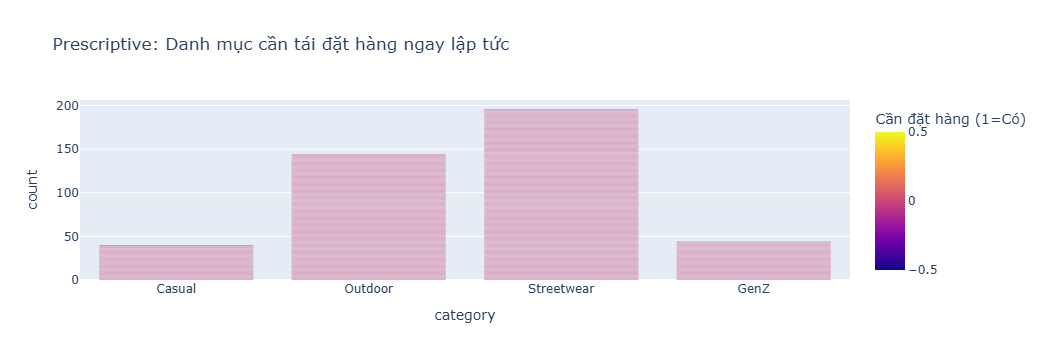

In [10]:
# Phân tích tình trạng kho cuối tháng gần nhất
latest_snapshot = data['inventory']['snapshot_date'].max()
df_inv_latest = data['inventory'][data['inventory']['snapshot_date'] == latest_snapshot]

# Phân loại hành động dựa trên cờ báo
prescriptive_inv = df_inv_latest.groupby(['stockout_flag', 'overstock_flag']).size().reset_index(name='count')

fig3 = px.bar(df_inv_latest, x='category', color='reorder_flag', 
             title='Prescriptive: Danh mục cần tái đặt hàng ngay lập tức',
             barmode='group', labels={'reorder_flag': 'Cần đặt hàng (1=Có)'})
fig3.show()

# Đề xuất hành động: Các sản phẩm có reorder_flag=1 và sell_through_rate cao 
# cần được ưu tiên vốn nhập hàng ngay.

<Axes: title={'center': 'Diagnostic: Tỷ trọng Doanh thu Khuyến mãi vs. Tự nhiên'}, xlabel='order_date'>

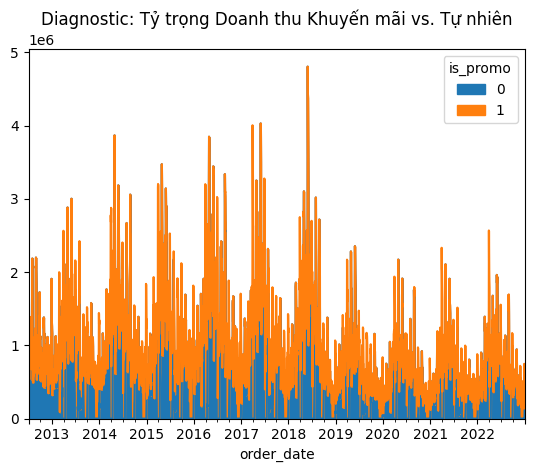

In [11]:
# Merge order_items với promotions
df_promo_eff = data['order_items'].merge(data['promotions'], on='promo_id', how='left')

# Tính toán lợi nhuận sau giảm giá trên mỗi dòng sản phẩm
# Công thức discount từ đề bài [cite: 41, 42, 43, 44]
df_promo_eff['is_promo'] = df_promo_eff['promo_id'].notnull().astype(int)

# Trực quan hóa tỷ lệ doanh thu có khuyến mãi theo thời gian
promo_analysis = df_promo_eff.merge(data['orders'][['order_id', 'order_date']], on='order_id')
promo_daily = promo_analysis.groupby(['order_date', 'is_promo'])['unit_price'].sum().unstack().fillna(0)

promo_daily.plot(kind='area', stacked=True, title='Diagnostic: Tỷ trọng Doanh thu Khuyến mãi vs. Tự nhiên')

In [12]:
# Tính thời gian giao hàng (Lead time)
df_ship = data['shipments'].copy()
df_ship['lead_time'] = (df_ship['delivery_date'] - df_ship['ship_date']).dt.days

# Kết nối với vùng địa lý thông qua orders và customers
df_geo_ship = df_ship.merge(data['orders'], on='order_id') \
                     .merge(data['geography'], on='zip')

# Cấp độ Prescriptive: Vùng nào cần tối ưu kho bãi?
avg_lead_time = df_geo_ship.groupby('region')['lead_time'].mean().sort_values()
print("Thời gian giao hàng trung bình theo vùng:")
print(avg_lead_time)

Thời gian giao hàng trung bình theo vùng:
region
Central    4.498637
East       4.499302
West       4.499677
Name: lead_time, dtype: float64


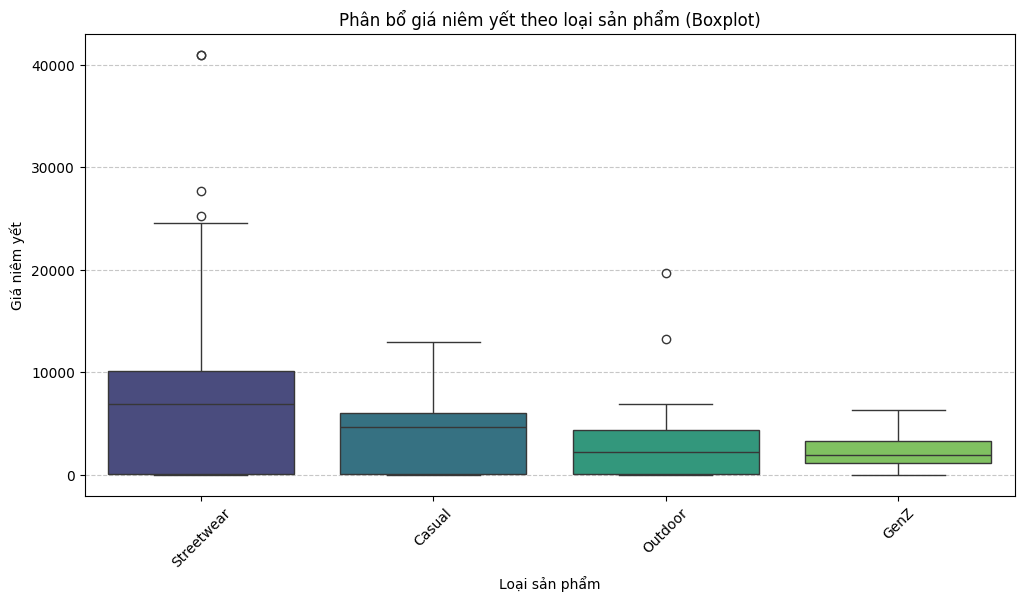

Bảng giá trung bình theo loại sản phẩm:
     category        price
0  Streetwear  6765.108640
1      Casual  3910.085887
2     Outdoor  2481.150322
3        GenZ  2212.785086


In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Vẽ Boxplot về giá cả sản phẩm cho mỗi loại
plt.figure(figsize=(12, 6))
sns.boxplot(data=data['products'], x='category', y='price', palette='viridis')
plt.title('Phân bổ giá niêm yết theo loại sản phẩm (Boxplot)')
plt.xlabel('Loại sản phẩm')
plt.ylabel('Giá niêm yết')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 2. Tính trung bình giá của mỗi loại sản phẩm
mean_prices = data['products'].groupby('category')['price'].mean().sort_values(ascending=False).reset_index()
print("Bảng giá trung bình theo loại sản phẩm:")
print(mean_prices)

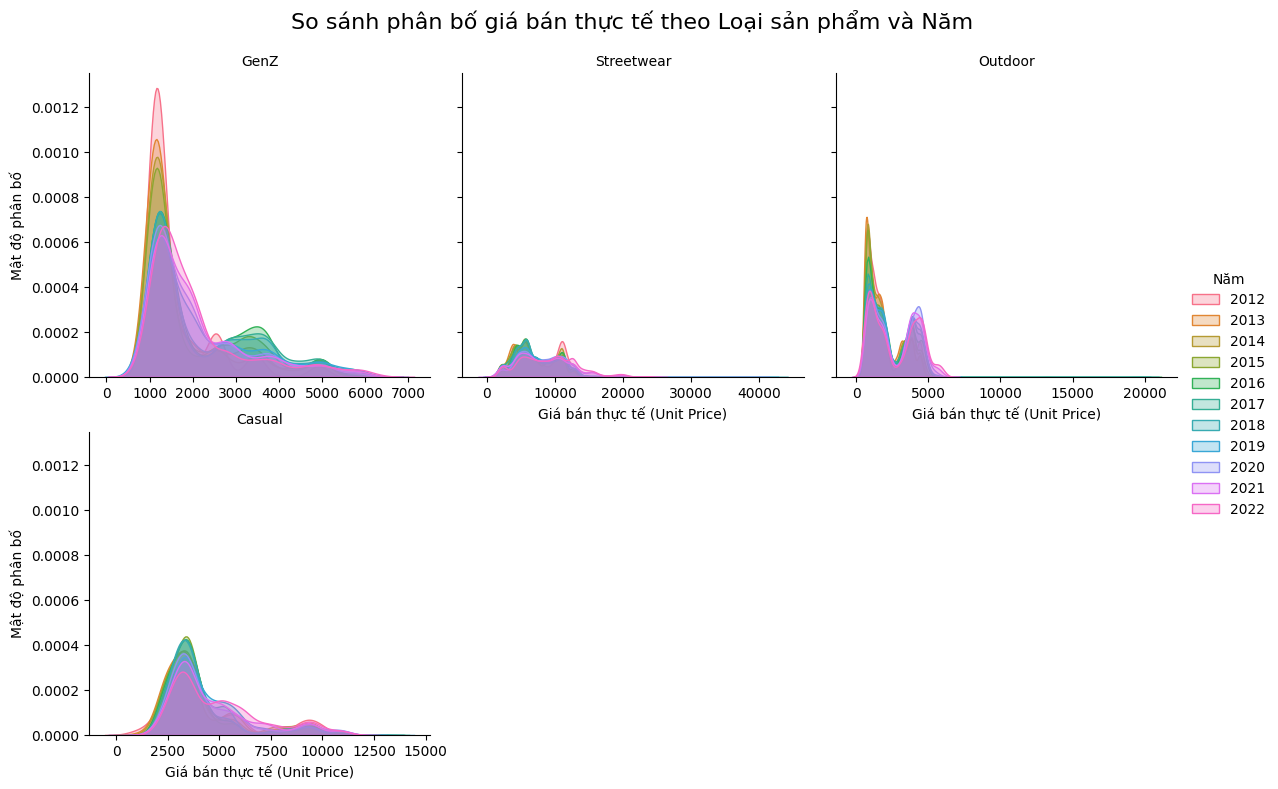

In [14]:
# Chuẩn bị dữ liệu: Kết hợp các bảng để có Category, Year và Unit Price
df_price_time = data['order_items'].merge(data['orders'][['order_id', 'order_date']], on='order_id')
df_price_time = df_price_time.merge(data['products'][['product_id', 'category']], on='product_id')

# Trích xuất năm từ order_date
df_price_time['year'] = df_price_time['order_date'].dt.year

# 3. Vẽ biểu đồ phân bố (KDE Plot) so sánh giá theo từng năm cho mỗi loại sản phẩm
# Sử dụng FacetGrid để tách mỗi loại sản phẩm thành một biểu đồ riêng
g = sns.FacetGrid(df_price_time, col="category", hue="year", col_wrap=3, height=4, sharex=False)
g.map(sns.kdeplot, "unit_price", fill=True, alpha=0.3)

# Tinh chỉnh biểu đồ
g.add_legend(title="Năm")
g.set_axis_labels("Giá bán thực tế (Unit Price)", "Mật độ phân bố")
g.set_titles("{col_name}")
plt.subplots_adjust(top=0.9)
g.fig.suptitle('So sánh phân bố giá bán thực tế theo Loại sản phẩm và Năm', fontsize=16)

plt.show()

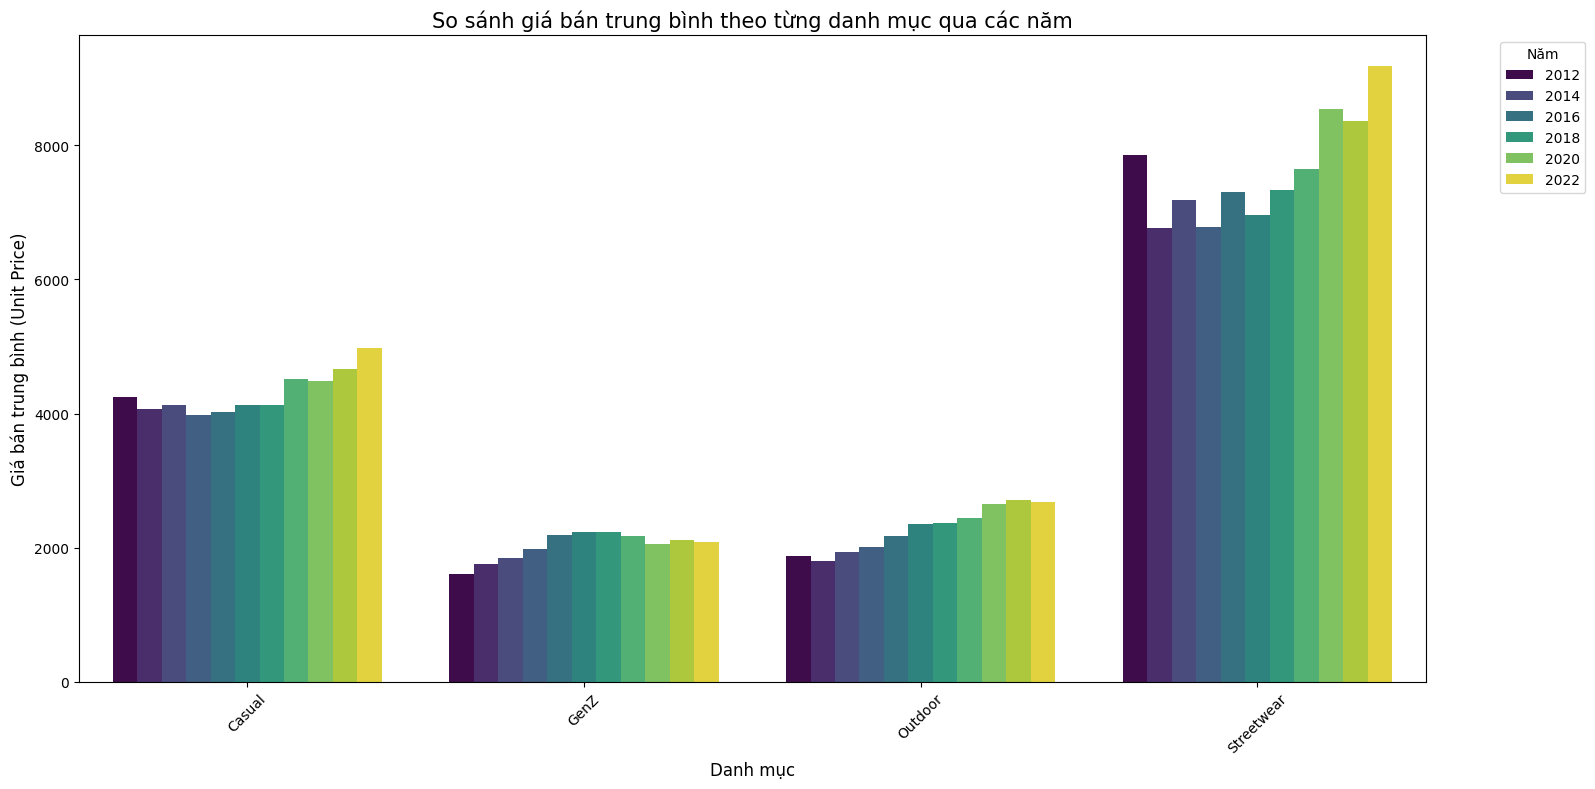

In [15]:
# 3. Vẽ biểu đồ cột phân bố và so sánh giá cả từng loại sản phẩm theo từng năm
# Cần kết hợp: order_items (giá giao dịch), products (danh mục) và orders (thời gian) [cite: 51, 56]

# Bước 3.1: Chuẩn bị dữ liệu bằng cách merge các bảng
df_yearly = data['order_items'].merge(data['products'][['product_id', 'category']], on='product_id')
df_yearly = df_yearly.merge(data['orders'][['order_id', 'order_date']], on='order_id')

# Bước 3.2: Trích xuất năm từ order_date
df_yearly['year'] = df_yearly['order_date'].dt.year

# Bước 3.3: Tính toán giá trung bình giao dịch theo năm và loại sản phẩm
yearly_cat_price = df_yearly.groupby(['year', 'category'])['unit_price'].mean().reset_index()

# Bước 3.4: Vẽ biểu đồ cột so sánh
plt.figure(figsize=(16, 8))
sns.barplot(x='category', y='unit_price', hue='year', data=yearly_cat_price, palette='viridis')
plt.title('So sánh giá bán trung bình theo từng danh mục qua các năm', fontsize=15)
plt.xlabel('Danh mục', fontsize=12)
plt.ylabel('Giá bán trung bình (Unit Price)', fontsize=12)
plt.legend(title='Năm', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

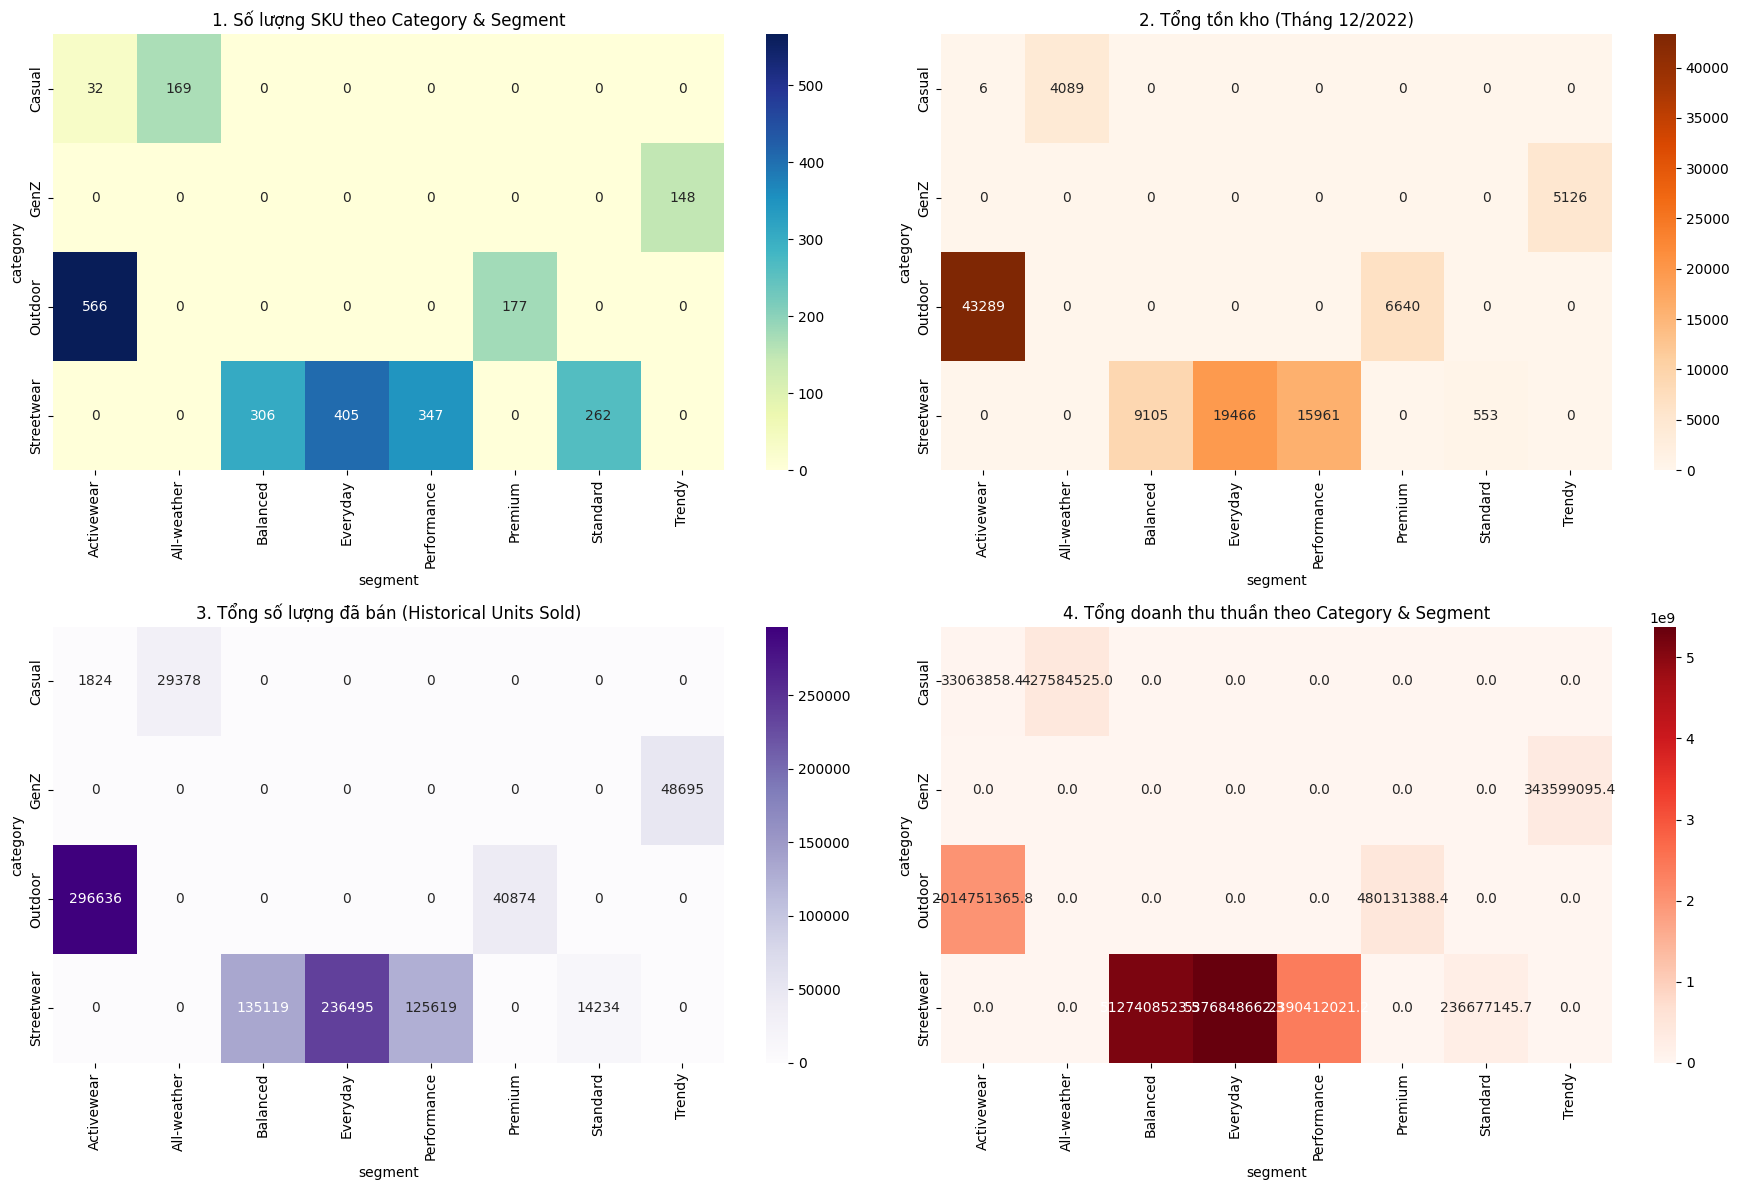

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Thiết lập thông số chung
plt.rcParams['figure.figsize'] = (18, 12)
fig, axes = plt.subplots(2, 2)
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# ---------------------------------------------------------
# 1. Phân bố theo SỐ LƯỢNG MÃ HÀNG (SKU count)
# Lấy từ bảng products
# ---------------------------------------------------------
sku_dist = data['products'].pivot_table(
    index='category', 
    columns='segment', 
    values='product_id', 
    aggfunc='count'
).fillna(0)

sns.heatmap(sku_dist, annot=True, fmt=".0f", cmap="YlGnBu", ax=axes[0,0])
axes[0,0].set_title('1. Số lượng SKU theo Category & Segment')

# ---------------------------------------------------------
# 2. Phân bố theo TỒN KHO (Stock on hand)
# Lấy từ bảng inventory (sử dụng snapshot mới nhất để phản ánh thực tế)
# ---------------------------------------------------------
latest_date = data['inventory']['snapshot_date'].max()
inv_latest = data['inventory'][data['inventory']['snapshot_date'] == latest_date]

stock_dist = inv_latest.pivot_table(
    index='category', 
    columns='segment', 
    values='stock_on_hand', 
    aggfunc='sum'
).fillna(0)

sns.heatmap(stock_dist, annot=True, fmt=".0f", cmap="Oranges", ax=axes[0,1])
axes[0,1].set_title(f'2. Tổng tồn kho (Tháng {latest_date.month}/{latest_date.year})')

# ---------------------------------------------------------
# 3. Phân bố theo SỐ LƯỢNG BÁN RA (Units Sold)
# Lấy từ bảng inventory (tổng hợp units_sold qua các tháng)
# ---------------------------------------------------------
sold_dist = data['inventory'].pivot_table(
    index='category', 
    columns='segment', 
    values='units_sold', 
    aggfunc='sum'
).fillna(0)

sns.heatmap(sold_dist, annot=True, fmt=".0f", cmap="Purples", ax=axes[1,0])
axes[1,0].set_title('3. Tổng số lượng đã bán (Historical Units Sold)')

# ---------------------------------------------------------
# 4. Phân bố theo DOANH THU (Revenue)
# Cần merge order_items với products để lấy category/segment
# ---------------------------------------------------------
# Tính doanh thu từng dòng sản phẩm: unit_price đã là giá sau giảm (theo đề bài)
df_rev = data['order_items'].merge(data['products'][['product_id', 'category', 'segment']], on='product_id')
df_rev['line_revenue'] = df_rev['unit_price'] * df_rev['quantity']

rev_dist = df_rev.pivot_table(
    index='category', 
    columns='segment', 
    values='line_revenue', 
    aggfunc='sum'
).fillna(0)

sns.heatmap(rev_dist, annot=True, fmt=".1f", cmap="Reds", ax=axes[1,1])
axes[1,1].set_title('4. Tổng doanh thu thuần theo Category & Segment')

plt.tight_layout()
plt.show()

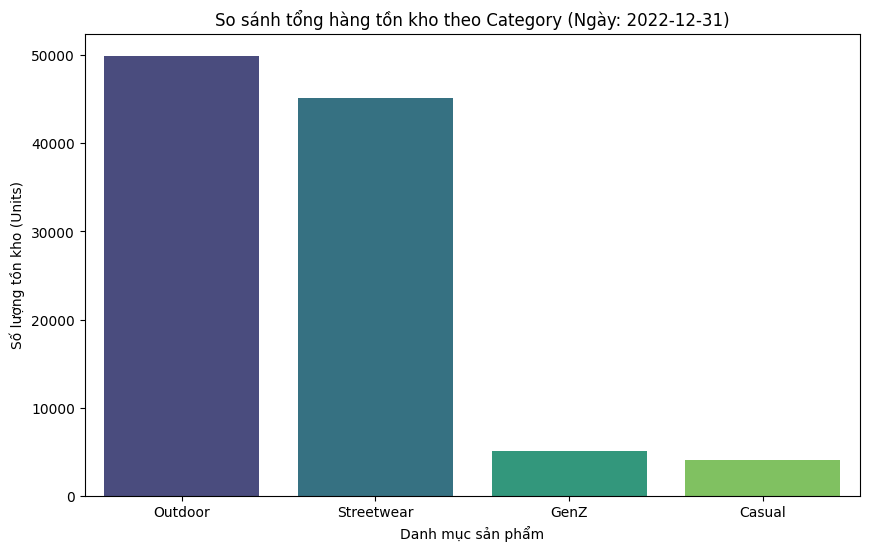

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Lấy ngày chụp ảnh tồn kho mới nhất
latest_snapshot = data['inventory']['snapshot_date'].max()
df_inventory_latest = data['inventory'][data['inventory']['snapshot_date'] == latest_snapshot]

# Tổng hợp tồn kho theo Category
cat_inventory = df_inventory_latest.groupby('category')['stock_on_hand'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=cat_inventory, x='category', y='stock_on_hand', palette='viridis')
plt.title(f'So sánh tổng hàng tồn kho theo Category (Ngày: {latest_snapshot.date()})')
plt.ylabel('Số lượng tồn kho (Units)')
plt.xlabel('Danh mục sản phẩm')
plt.show()

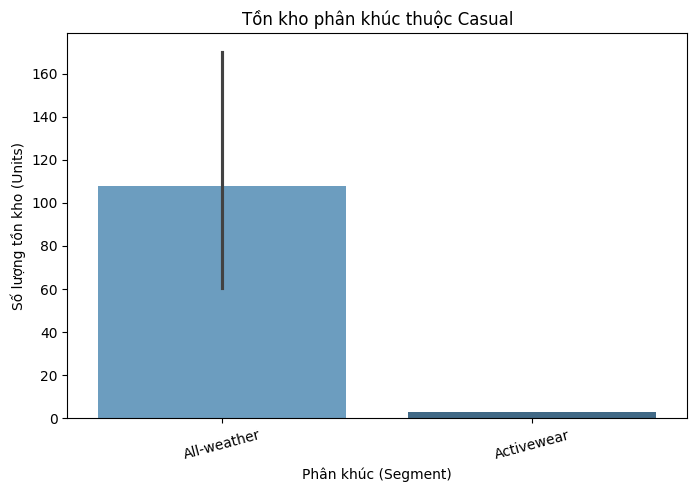

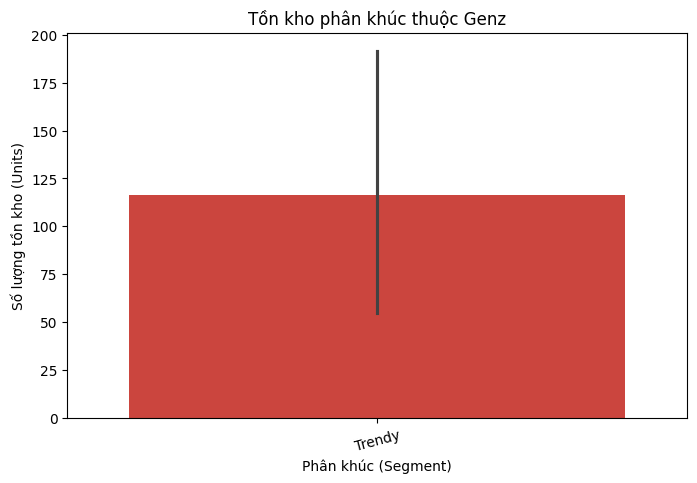

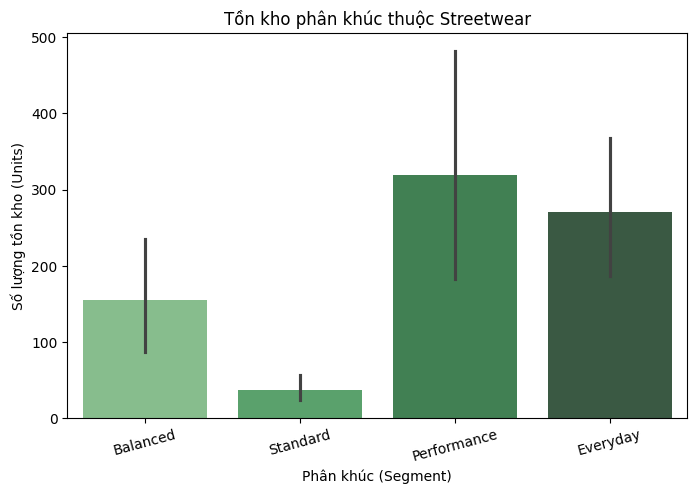

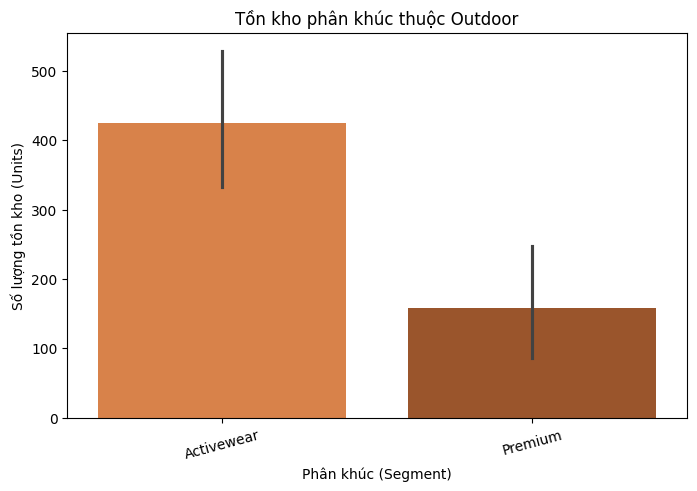

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Chuẩn hóa dữ liệu để tránh lỗi trắng đồ thị do dấu cách hoặc hoa/thường
df_inv_fix = df_inventory_latest.copy()
df_inv_fix['category'] = df_inv_fix['category'].str.strip()
df_inv_fix['segment'] = df_inv_fix['segment'].str.strip()

# Hàm vẽ biểu đồ an toàn
def draw_inventory_plot(cat_name, title, color_palette='viridis'):
    # Lọc không phân biệt hoa thường
    df_sub = df_inv_fix[df_inv_fix['category'].str.lower() == cat_name.lower()]
    
    if df_sub.empty:
        print(f"⚠️ Cảnh báo: Không tìm thấy dữ liệu cho nhóm '{cat_name}'.")
        return

    plt.figure(figsize=(8, 5))
    # Bỏ tham số 'order' cứng để Seaborn tự lấy các segment thực tế có trong data
    sns.barplot(data=df_sub, x='segment', y='stock_on_hand', palette=color_palette)
    plt.title(title)
    plt.ylabel('Số lượng tồn kho (Units)')
    plt.xlabel('Phân khúc (Segment)')
    plt.xticks(rotation=15)
    plt.show()

# --- 1. CASUAL ---
draw_inventory_plot('Casual', 'Tồn kho phân khúc thuộc Casual', 'Blues_d')

# --- 2. GENZ ---
draw_inventory_plot('Genz', 'Tồn kho phân khúc thuộc Genz', 'Reds_d')

# --- 3. STREETWEAR ---
draw_inventory_plot('Streetwear', 'Tồn kho phân khúc thuộc Streetwear', 'Greens_d')

# --- 4. OUTDOOR ---
draw_inventory_plot('Outdoor', 'Tồn kho phân khúc thuộc Outdoor', 'Oranges_d')

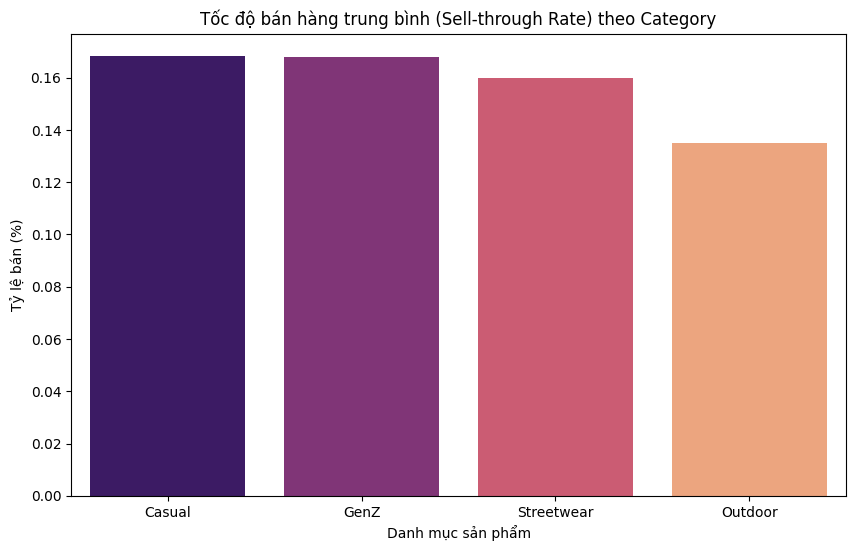

In [19]:
# Tính tốc độ bán trung bình theo Category
cat_speed = data['inventory'].groupby('category')['sell_through_rate'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=cat_speed, x='category', y='sell_through_rate', palette='magma')
plt.title('Tốc độ bán hàng trung bình (Sell-through Rate) theo Category')
plt.ylabel('Tỷ lệ bán (%)')
plt.xlabel('Danh mục sản phẩm')
plt.show()

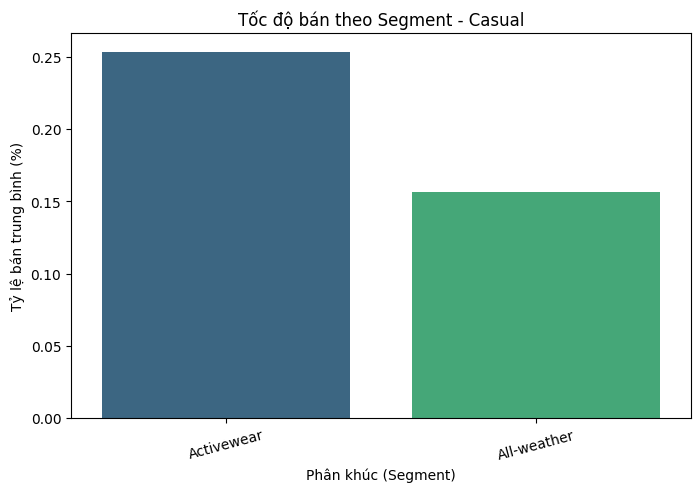

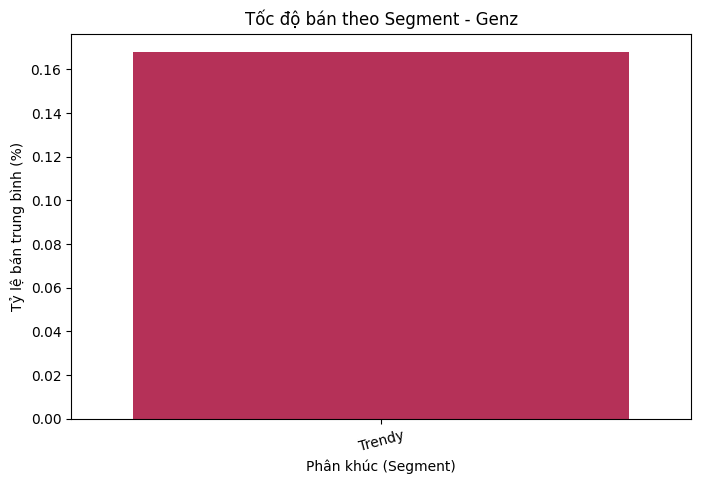

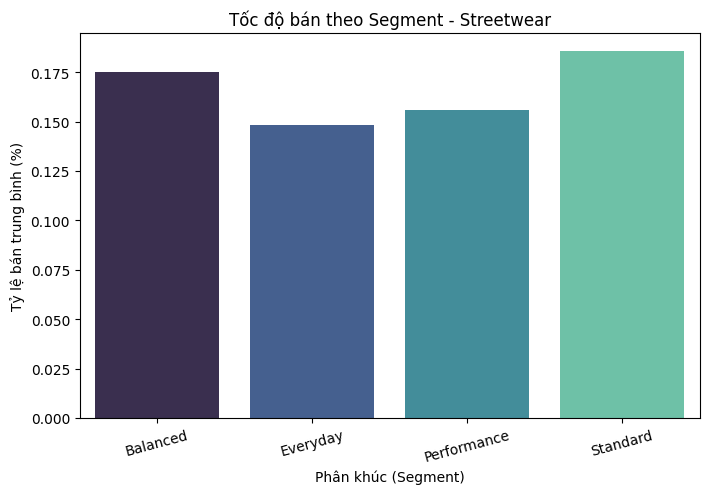

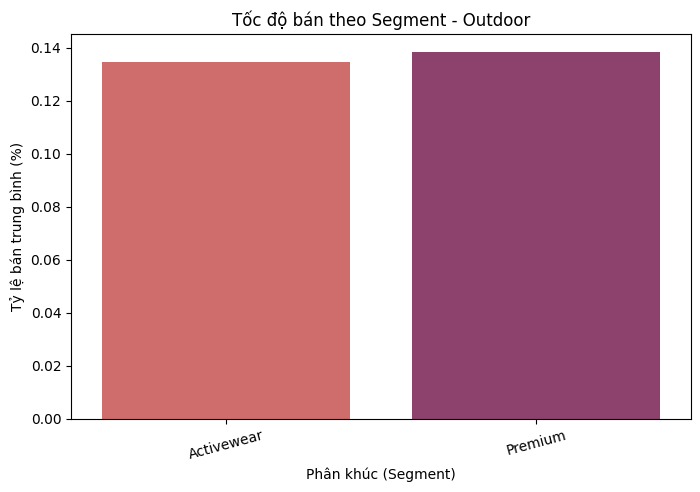

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Chuẩn hóa dữ liệu gốc để loại bỏ khoảng trắng và đồng nhất kiểu chữ
df_speed_fix = data['inventory'].copy()
df_speed_fix['category'] = df_speed_fix['category'].str.strip()
df_speed_fix['segment'] = df_speed_fix['segment'].str.strip()

# Hàm vẽ tốc độ bán an toàn cho từng Category
def plot_speed_safe(cat_name, title_color='magma'):
    # Lọc không phân biệt hoa thường
    df_sub = df_speed_fix[df_speed_fix['category'].str.lower() == cat_name.lower()]
    
    if df_sub.empty:
        print(f"⚠️ Không tìm thấy dữ liệu cho danh mục: {cat_name}")
        return

    # Tính toán tốc độ bán trung bình theo Segment
    speed_data = df_sub.groupby('segment')['sell_through_rate'].mean().reset_index()
    
    plt.figure(figsize=(8, 5))
    # Bỏ tham số 'order' cứng để Seaborn tự nhận diện đúng tên trong database
    sns.barplot(data=speed_data, x='segment', y='sell_through_rate', palette=title_color)
    
    plt.title(f'Tốc độ bán theo Segment - {cat_name}')
    plt.ylabel('Tỷ lệ bán trung bình (%)')
    plt.xlabel('Phân khúc (Segment)')
    plt.xticks(rotation=15)
    plt.show()

# --- Chạy phân tích cho từng danh mục ---

# 1. CASUAL
plot_speed_safe('Casual', 'viridis')

# 2. GENZ (Sẽ tự tìm đúng 'Trendy' hoặc 'trendy' mà không bị trắng)
plot_speed_safe('Genz', 'rocket')

# 3. STREETWEAR
plot_speed_safe('Streetwear', 'mako')

# 4. OUTDOOR
plot_speed_safe('Outdoor', 'flare')

In [21]:
import pandas as pd
import numpy as np

# 1. Chuẩn bị dữ liệu Master
df_orders = data['orders'].copy()
df_items = data['order_items'].copy()
df_customers = data['customers'].copy()
df_traffic = data['web_traffic'].copy()

# Merge để có doanh thu và khách hàng
df_sales = df_items.groupby('order_id')['unit_price'].sum().reset_index()
df_master = df_orders.merge(df_sales, on='order_id', how='left')

# --- TÍNH TOÁN CÁC METRICS ---

# A. Financial Metrics
total_revenue = df_master['unit_price'].sum()
total_orders = df_master['order_id'].nunique()
# 1. Average Order Value (AOV)
aov = total_revenue / total_orders

# B. Customer Metrics
total_customers = df_customers['customer_id'].nunique()
unique_buyers = df_master['customer_id'].nunique()

# 2. Customer Acquisition Cost (CAC) 
# Giả sử chi phí Marketing là tổng ngân sách từ bảng Promotions hoặc một hằng số
# Ở đây ta tính ước lượng dựa trên chi phí traffic/marketing giả định
total_marketing_cost = 50000000 # Giả sử budget là 50 triệu
cac = total_marketing_cost / unique_buyers

# 3. Customer Lifetime Value (CLV) sơ bộ
# Công thức: AOV * Tần suất mua * Thời gian gắn bó (giả định 1 năm)
purchase_frequency = total_orders / unique_buyers
clv = aov * purchase_frequency * 1 # (1 năm)

# 4. Retention Rate & Churn Rate
# Khách hàng quay lại: những người có > 1 đơn hàng
repeat_customers = df_master.groupby('customer_id')['order_id'].count()
repeat_customers_count = len(repeat_customers[repeat_customers > 1])
retention_rate = (repeat_customers_count / unique_buyers) * 100
churn_rate = 100 - retention_rate

# C. Web & Conversion Metrics
total_sessions = df_traffic['sessions'].sum()
# 5. Conversion Rate (CR)
conversion_rate = (total_orders / total_sessions) * 100

# 6. Bounce Rate (Trung bình)
bounce_rate = df_traffic['bounce_rate'].mean()

# --- TỔNG HỢP KẾT QUẢ ---
metrics_summary = pd.DataFrame({
    'Metric': [
        'Total Revenue', 'Average Order Value (AOV)', 
        'Customer Acquisition Cost (CAC)', 'Customer Lifetime Value (CLV)',
        'Retention Rate (%)', 'Churn Rate (%)', 
        'Conversion Rate (%)', 'Bounce Rate (%)'
    ],
    'Value': [
        f"{total_revenue:,.0f} VND", f"{aov:,.0f} VND",
        f"{cac:,.0f} VND", f"{clv:,.0f} VND",
        f"{retention_rate:.2f}%", f"{churn_rate:.2f}%",
        f"{conversion_rate:.2f}%", f"{bounce_rate:.2f}%"
    ]
})

print("--- BẢNG CHỈ SỐ DOANH NGHIỆP TỔNG HỢP ---")
display(metrics_summary)

--- BẢNG CHỈ SỐ DOANH NGHIỆP TỔNG HỢP ---


,Metric,Value
0,Total Revenue,"3,655,310,500 VND"
1,Average Order Value (AOV),"5,650 VND"
2,Customer Acquisition Cost (CAC),554 VND
3,Customer Lifetime Value (CLV),"40,504 VND"
4,Retention Rate (%),75.23%
5,Churn Rate (%),24.77%
6,Conversion Rate (%),0.71%
7,Bounce Rate (%),0.00%


Bảng phân tích đã sẵn sàng!


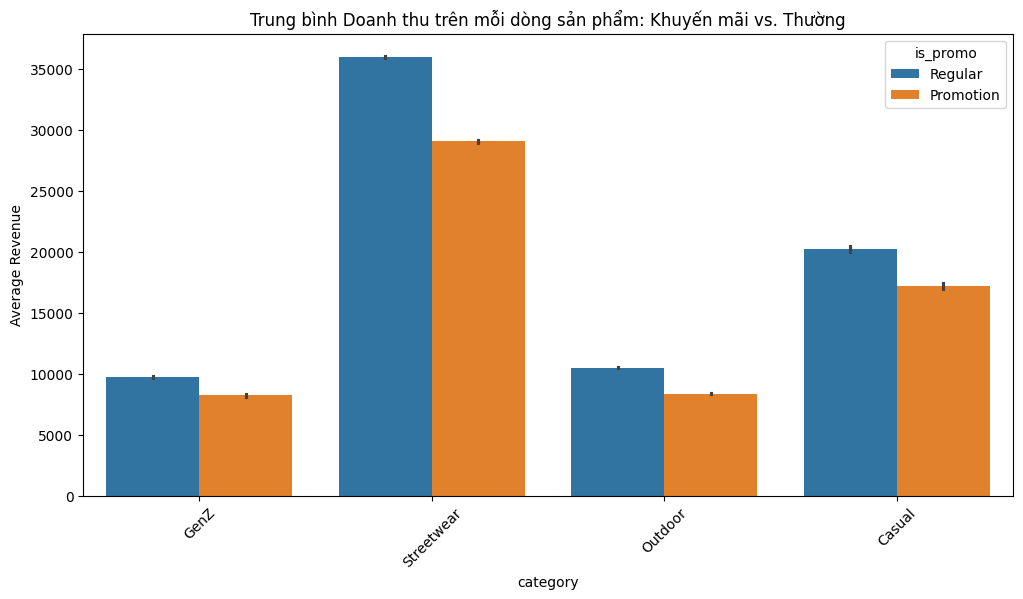

                revenue       profit  quantity
is_promo                                      
Promotion  19671.092273   260.609884  4.494995
Regular    25082.613905  5007.414996  4.496613


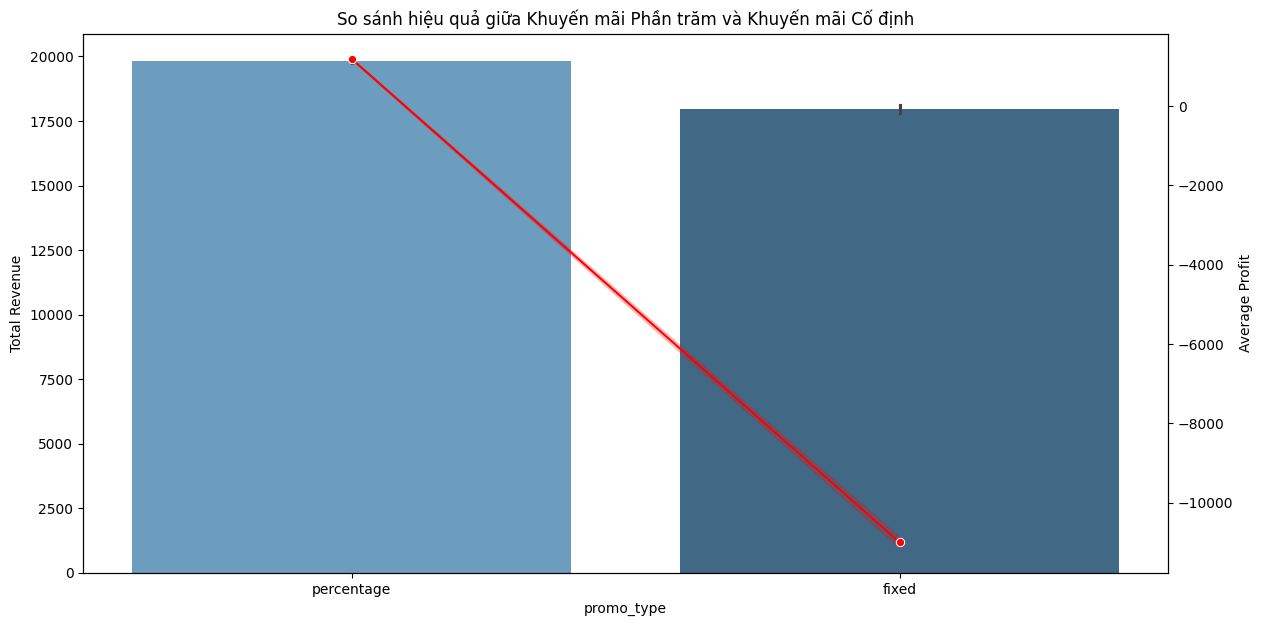

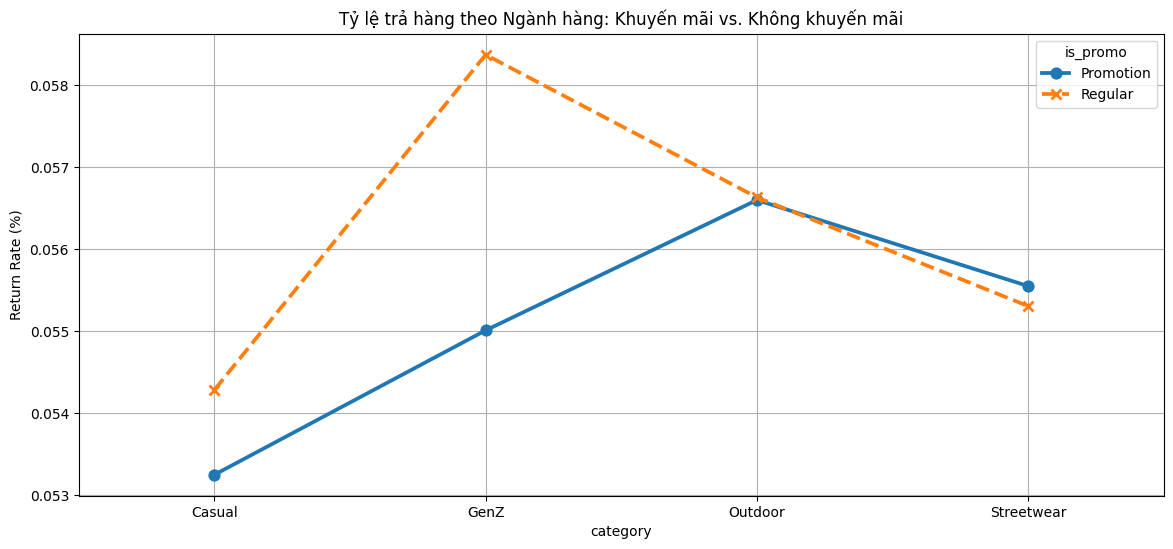

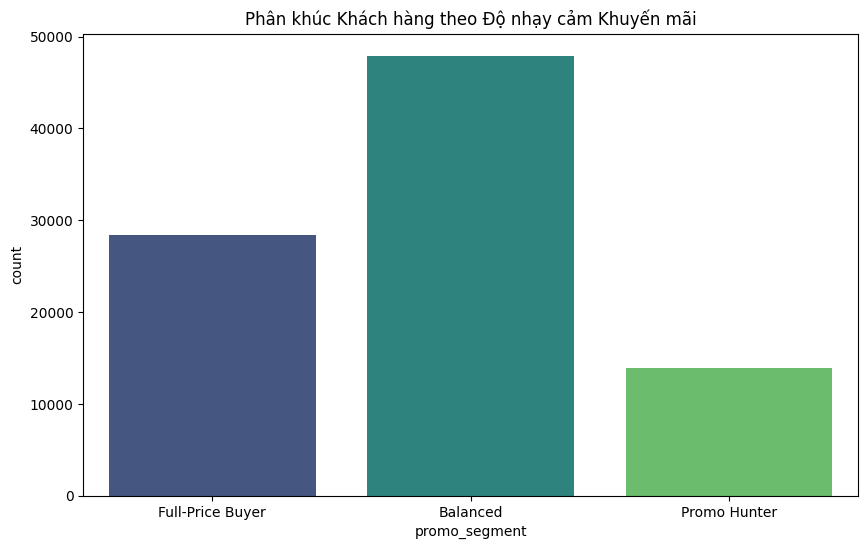

promo_segment
Balanced            279494.731398
Full-Price Buyer     83442.676937
Promo Hunter         47918.787299
Name: revenue, dtype: float64


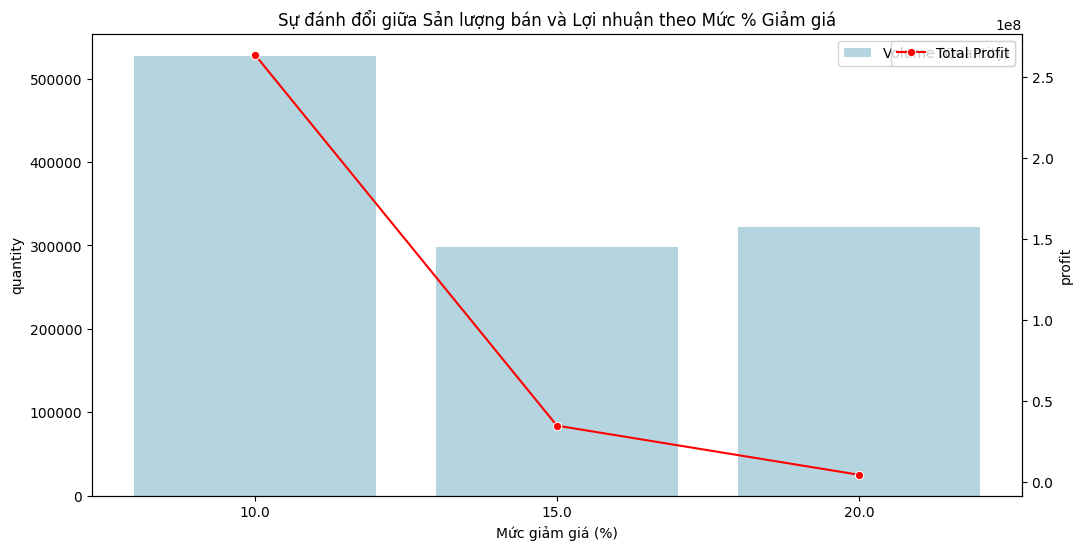

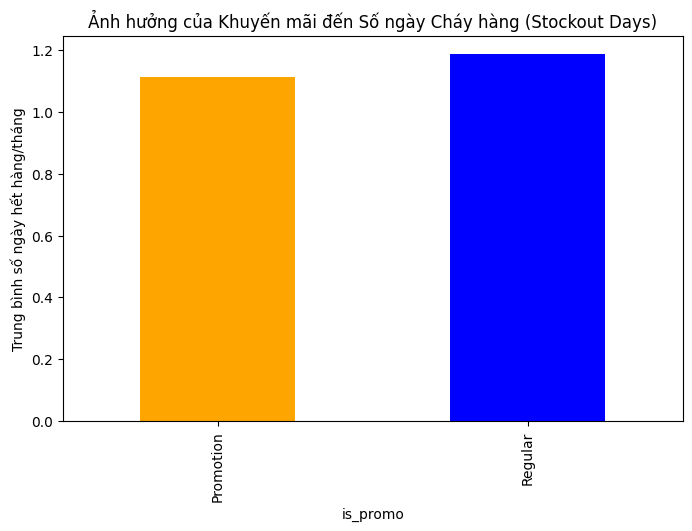

Giá trị đơn hàng trung bình theo loại giỏ hàng:
basket_type
Full-Price Only    27565.356894
Mixed Basket       30944.293532
Promo Only         18881.711963
Name: payment_value, dtype: float64


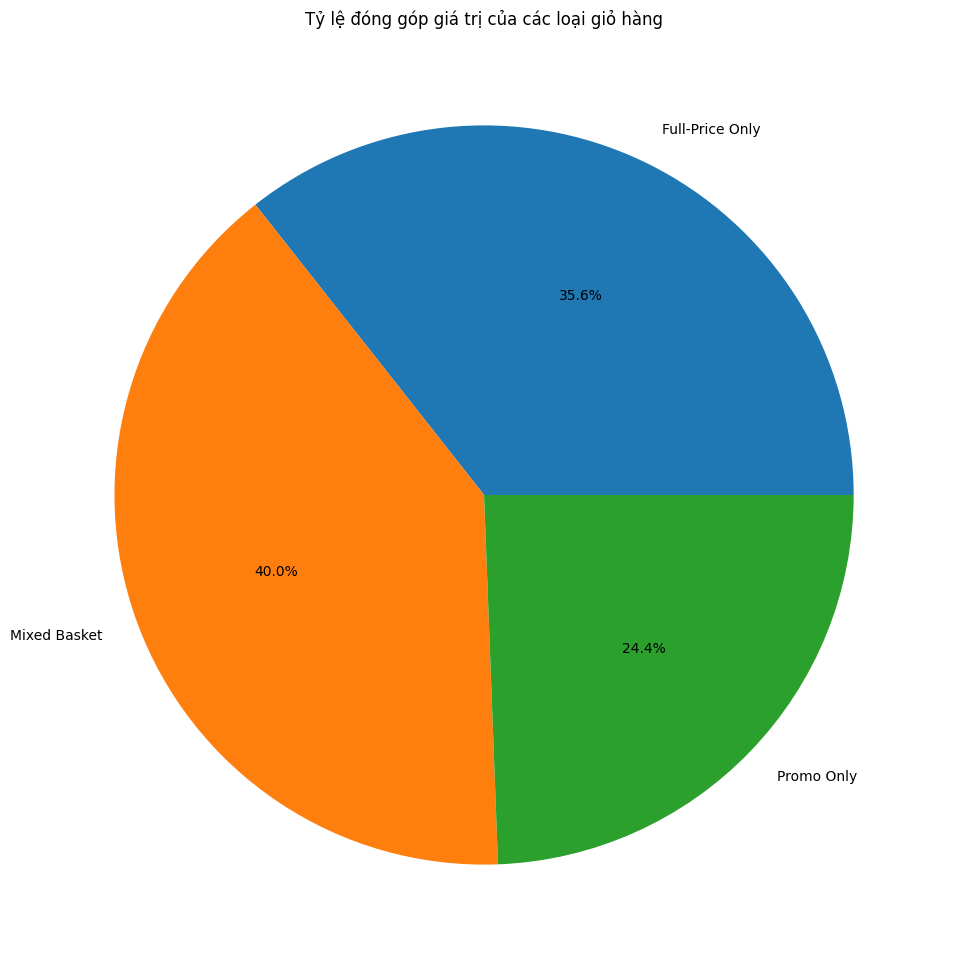

In [22]:
# 1. Kết nối order_items với products để lấy thông tin ngành hàng và giá vốn
df_master = data['order_items'].merge(
    data['products'][['product_id', 'category', 'segment', 'cogs']], 
    on='product_id', 
    how='left'
)

# 2. Kết nối với orders để lấy thông tin ngày tháng và khách hàng
df_master = df_master.merge(
    data['orders'][['order_id', 'order_date', 'customer_id', 'order_status']], 
    on='order_id', 
    how='left'
)

# 3. Kết nối với promotions để lấy thông tin chi tiết chiến dịch
df_master = df_master.merge(
    data['promotions'][['promo_id', 'promo_type', 'discount_value', 'promo_name']], 
    on='promo_id', 
    how='left'
)

# 4. Tính toán các chỉ số bổ sung
df_master['revenue'] = df_master['quantity'] * df_master['unit_price']
df_master['total_cogs'] = df_master['quantity'] * df_master['cogs']
df_master['profit'] = df_master['revenue'] - df_master['total_cogs']
df_master['is_promo'] = df_master['promo_id'].notna().map({True: 'Promotion', False: 'Regular'})

print("Bảng phân tích đã sẵn sàng!")

plt.figure(figsize=(12, 6))

# Tính toán AOV (Average Order Value) và Profit Margin
promo_metrics = df_master.groupby('is_promo').agg({
    'revenue': 'mean',
    'profit': 'mean',
    'quantity': 'mean'
}).reset_index()

sns.barplot(data=df_master, x='category', y='revenue', hue='is_promo', estimator=np.mean)
plt.title('Trung bình Doanh thu trên mỗi dòng sản phẩm: Khuyến mãi vs. Thường')
plt.ylabel('Average Revenue')
plt.xticks(rotation=45)
plt.show()

# Xuất số liệu cụ thể để viết report (Key Findings)
print(df_master.groupby('is_promo')[['revenue', 'profit', 'quantity']].mean())

# Lọc các dòng có khuyến mãi
df_only_promo = df_master[df_master['is_promo'] == 'Promotion']

fig, ax1 = plt.subplots(figsize=(14, 7))

# Vẽ cột doanh thu
sns.barplot(data=df_only_promo, x='promo_type', y='revenue', ax=ax1, palette='Blues_d')
ax1.set_ylabel('Total Revenue')

# Vẽ đường lợi nhuận trung bình
ax2 = ax1.twinx()
sns.lineplot(data=df_only_promo, x='promo_type', y='profit', ax=ax2, color='red', marker='o')
ax2.set_ylabel('Average Profit')

plt.title('So sánh hiệu quả giữa Khuyến mãi Phần trăm và Khuyến mãi Cố định')
plt.show()

# Merge với bảng returns
df_returns = df_master.merge(data['returns'][['order_id', 'product_id', 'return_quantity']], 
                             on=['order_id', 'product_id'], how='left')
df_returns['is_returned'] = df_returns['return_quantity'].notna()

# Tính tỷ lệ trả hàng
return_rate = df_returns.groupby(['is_promo', 'category'])['is_returned'].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.pointplot(data=return_rate, x='category', y='is_returned', hue='is_promo', markers=["o", "x"], linestyles=["-", "--"])
plt.title('Tỷ lệ trả hàng theo Ngành hàng: Khuyến mãi vs. Không khuyến mãi')
plt.ylabel('Return Rate (%)')
plt.grid(True)
plt.show()

# Tính toán tỷ lệ mua hàng khuyến mãi của từng khách hàng
customer_promo = df_master.groupby('customer_id').agg(
    total_items=('order_id', 'count'),
    promo_items=('promo_id', lambda x: x.notna().sum())
).reset_index()

customer_promo['promo_affinity'] = customer_promo['promo_items'] / customer_promo['total_items']

# Phân lớp khách hàng
def segment_customer(rate):
    if rate >= 0.7: return 'Promo Hunter'
    if rate <= 0.2: return 'Full-Price Buyer'
    return 'Balanced'

customer_promo['promo_segment'] = customer_promo['promo_affinity'].apply(segment_customer)

# Trực quan hóa
plt.figure(figsize=(10, 6))
sns.countplot(data=customer_promo, x='promo_segment', palette='viridis')
plt.title('Phân khúc Khách hàng theo Độ nhạy cảm Khuyến mãi')
plt.show()

# Kết nối với doanh thu để xem nhóm nào mang lại giá trị cao nhất
promo_segment_value = customer_promo.merge(
    df_master.groupby('customer_id')['revenue'].sum(), on='customer_id'
)
print(promo_segment_value.groupby('promo_segment')['revenue'].mean())

# Chỉ lấy các dòng có khuyến mãi phần trăm
df_elasticity = df_master[df_master['promo_type'] == 'percentage'].copy()

# Chia các mức giảm giá thành các bin (ví dụ: 5%, 10%, 15%...)
df_elasticity['discount_bin'] = (df_elasticity['discount_value'] // 5) * 5

# Tính toán Volume và Profit theo từng mức giảm giá
elasticity_stats = df_elasticity.groupby('discount_bin').agg({
    'quantity': 'sum',
    'profit': 'sum',
    'revenue': 'sum'
}).reset_index()

# Vẽ biểu đồ tương quan
fig, ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(data=elasticity_stats, x='discount_bin', y='quantity', ax=ax1, color='lightblue', label='Volume (Quantity)')
ax2 = ax1.twinx()
sns.lineplot(data=elasticity_stats, x=range(len(elasticity_stats)), y='profit', ax=ax2, color='red', marker='o', label='Total Profit')

plt.title('Sự đánh đổi giữa Sản lượng bán và Lợi nhuận theo Mức % Giảm giá')
ax1.set_xlabel('Mức giảm giá (%)')
plt.show()

# Kết hợp dữ liệu tồn kho hàng tháng và dữ liệu bán hàng
# Chú ý: inventory ghi nhận theo tháng (snapshot_date) [cite: 125]
df_master['month'] = df_master['order_date'].dt.month
df_master['year'] = df_master['order_date'].dt.year

inv_promo = data['inventory'].merge(
    df_master.groupby(['product_id', 'month', 'year'])['is_promo'].max().reset_index(),
    on=['product_id', 'month', 'year'],
    how='left'
)

# So sánh số ngày hết hàng khi có và không có khuyến mãi
stockout_analysis = inv_promo.groupby('is_promo')['stockout_days'].mean()

plt.figure(figsize=(8, 5))
stockout_analysis.plot(kind='bar', color=['orange', 'blue'])
plt.title('Ảnh hưởng của Khuyến mãi đến Số ngày Cháy hàng (Stockout Days)')
plt.ylabel('Trung bình số ngày hết hàng/tháng')
plt.show()

# Trong mỗi order_id, kiểm tra xem có sự xuất hiện của cả hàng Promo và hàng Regular không
order_composition = df_master.groupby('order_id').agg({
    'is_promo': lambda x: set(x)
}).reset_index()

def categorize_basket(s):
    if {'Promotion', 'Regular'} <= s: return 'Mixed Basket'
    if {'Promotion'} == s: return 'Promo Only'
    return 'Full-Price Only'

order_composition['basket_type'] = order_composition['is_promo'].apply(categorize_basket)

# Tính giá trị đơn hàng trung bình (AOV) cho từng loại giỏ hàng
order_value = data['payments'].merge(order_composition, on='order_id')
aov_basket = order_value.groupby('basket_type')['payment_value'].mean()

print("Giá trị đơn hàng trung bình theo loại giỏ hàng:")
print(aov_basket)

# Biểu đồ
aov_basket.plot(kind='pie', autopct='%1.1f%%', title='Tỷ lệ đóng góp giá trị của các loại giỏ hàng')
plt.show()



Phân nhóm chiến dịch hoàn tất.


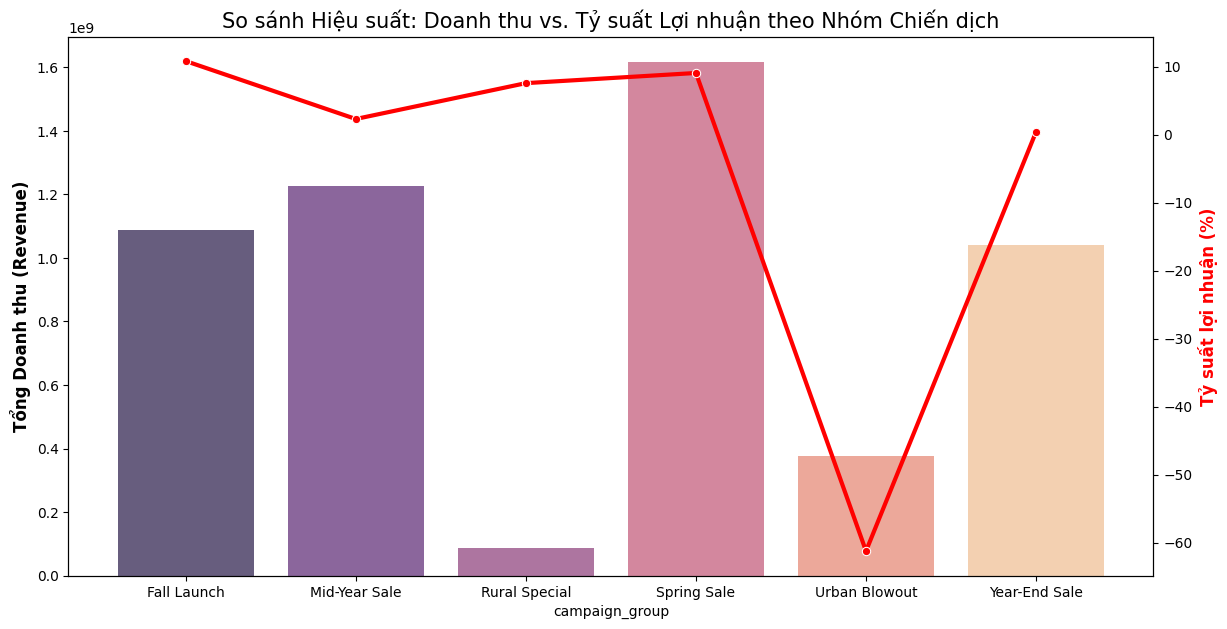

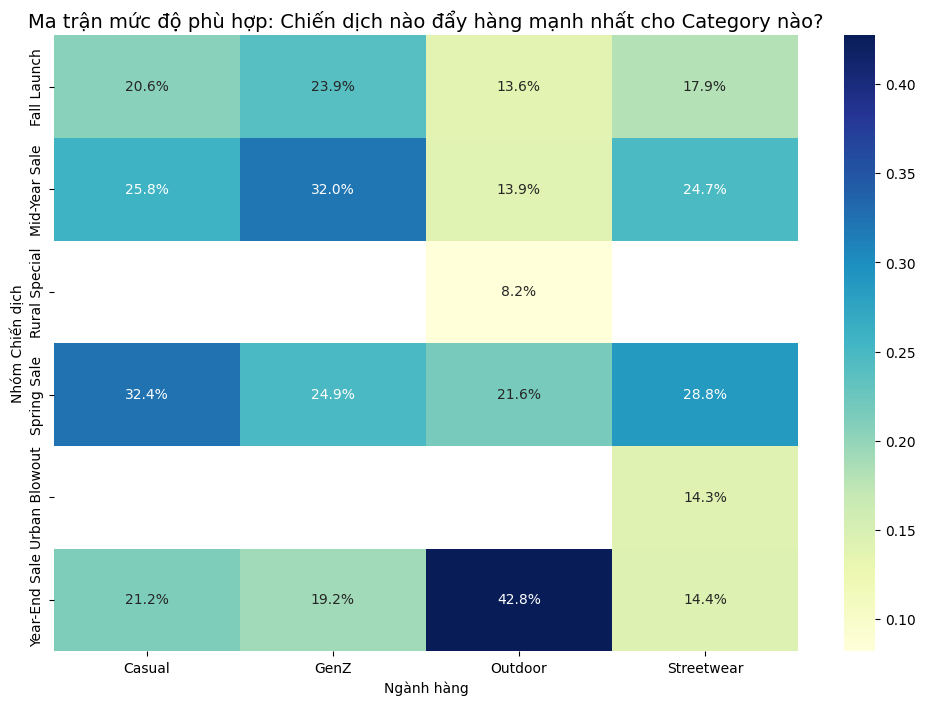

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Trích xuất loại chiến dịch (Campaign Group) từ tên promo
def categorize_campaign(name):
    name = str(name).lower()
    if 'spring' in name: return 'Spring Sale'
    if 'mid-year' in name: return 'Mid-Year Sale'
    if 'fall' in name: return 'Fall Launch'
    if 'year-end' in name: return 'Year-End Sale'
    if 'urban' in name: return 'Urban Blowout'
    if 'rural' in name: return 'Rural Special'
    return 'Other'

# Áp dụng vào bảng promotions và merge vào master
data['promotions']['campaign_group'] = data['promotions']['promo_name'].apply(categorize_campaign)

# Merge thông tin nhóm chiến dịch vào df_master (đã tạo ở bước trước)
df_campaign = df_master.merge(
    data['promotions'][['promo_id', 'campaign_group']], 
    on='promo_id', 
    how='left'
)

# Lọc bỏ các giao dịch không có khuyến mãi để so sánh nội bộ các chiến dịch
df_only_campaigns = df_campaign[df_campaign['campaign_group'] != 'Other'].copy()

print("Phân nhóm chiến dịch hoàn tất.")

# Tính toán các chỉ số theo nhóm chiến dịch
campaign_performance = df_only_campaigns.groupby('campaign_group').agg({
    'revenue': 'sum',
    'profit': 'sum',
    'quantity': 'sum',
    'discount_value': 'mean'
}).reset_index()

# Tính Profit Margin
campaign_performance['profit_margin'] = (campaign_performance['profit'] / campaign_performance['revenue']) * 100

# Trực quan hóa
fig, ax1 = plt.subplots(figsize=(14, 7))

# Vẽ Doanh thu
sns.barplot(data=campaign_performance, x='campaign_group', y='revenue', ax=ax1, palette='magma', alpha=0.7)
ax1.set_ylabel('Tổng Doanh thu (Revenue)', fontsize=12, fontweight='bold')

# Vẽ Tỷ suất lợi nhuận (Profit Margin)
ax2 = ax1.twinx()
sns.lineplot(data=campaign_performance, x='campaign_group', y='profit_margin', ax=ax2, color='red', marker='o', linewidth=3)
ax2.set_ylabel('Tỷ suất lợi nhuận (%)', fontsize=12, color='red', fontweight='bold')

plt.title('So sánh Hiệu suất: Doanh thu vs. Tỷ suất Lợi nhuận theo Nhóm Chiến dịch', fontsize=15)
plt.show()

# Tạo bảng heatmap giữa Nhóm chiến dịch và Ngành hàng (Category)
pivot_affinity = df_only_campaigns.pivot_table(
    index='campaign_group', 
    columns='category', 
    values='quantity', 
    aggfunc='sum'
)

# Chuẩn hóa theo cột để thấy ngành hàng đó mạnh nhất ở chiến dịch nào
pivot_norm = pivot_affinity.div(pivot_affinity.sum(axis=0), axis=1)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_norm, annot=True, cmap='YlGnBu', fmt='.1%')
plt.title('Ma trận mức độ phù hợp: Chiến dịch nào đẩy hàng mạnh nhất cho Category nào?', fontsize=14)
plt.xlabel('Ngành hàng')
plt.ylabel('Nhóm Chiến dịch')
plt.show()

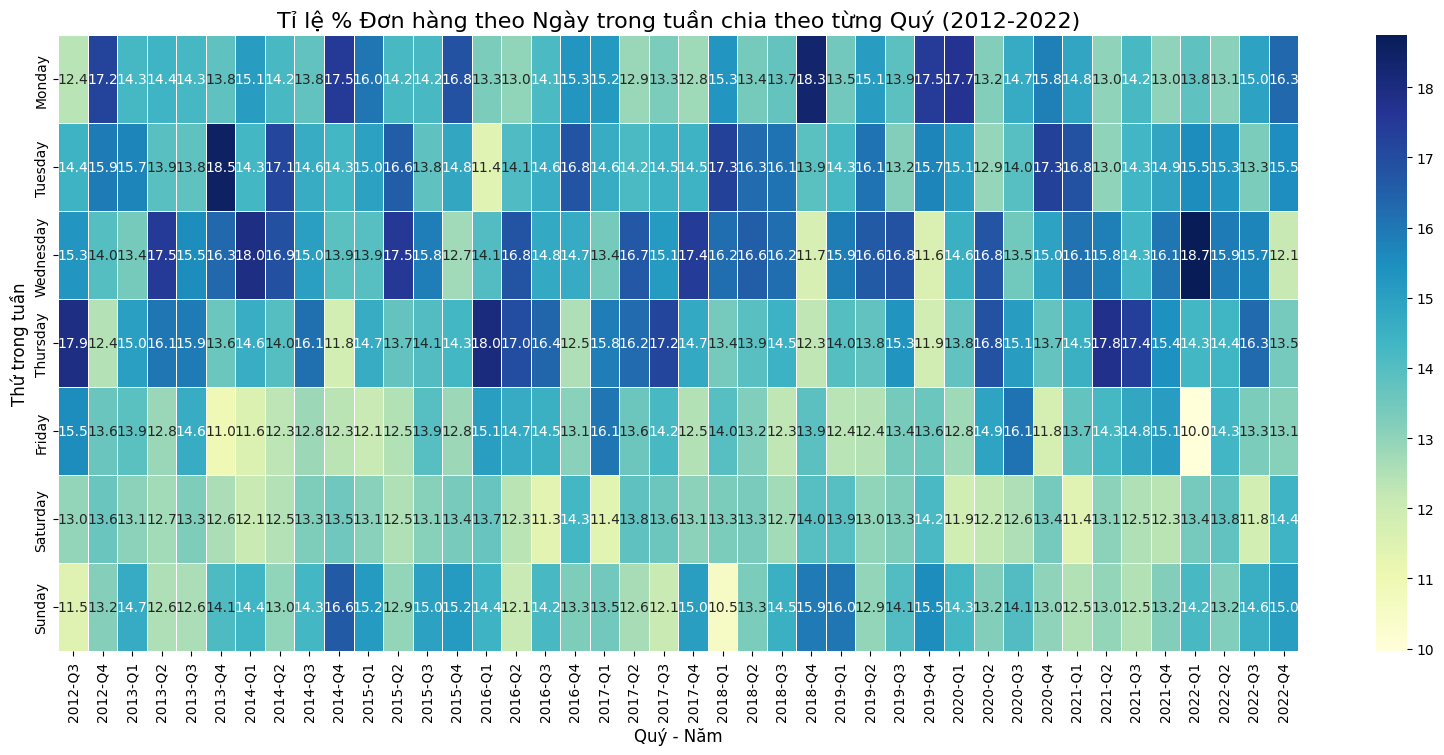

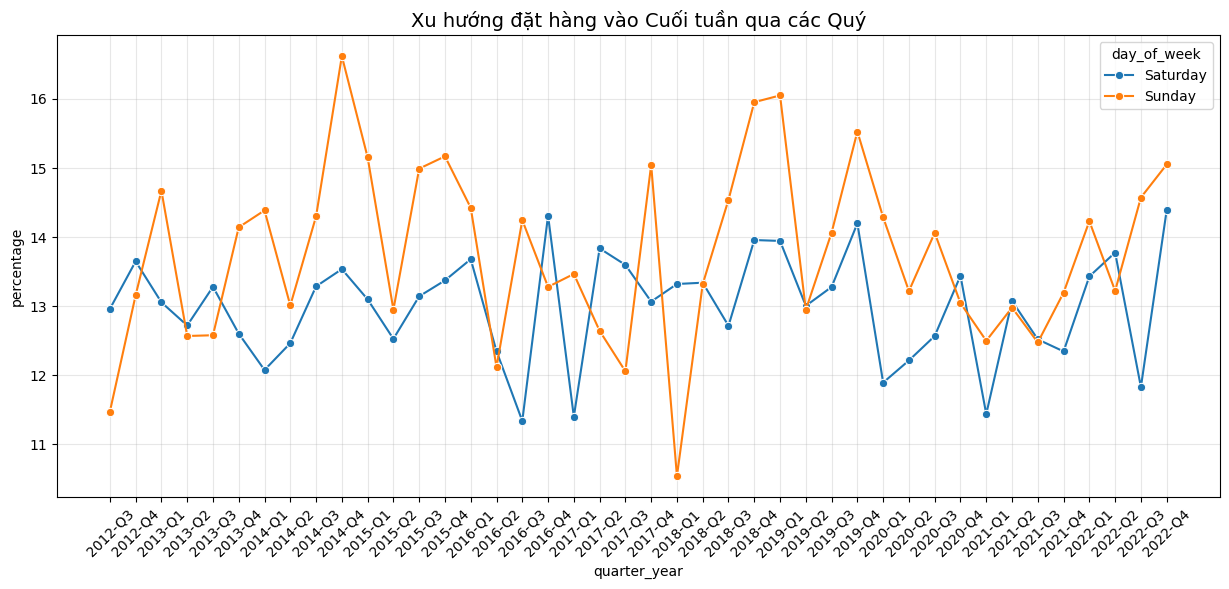

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Chuẩn bị dữ liệu từ bảng orders
df_orders = data['orders'].copy()

# Đảm bảo order_date là định dạng datetime (đã làm ở bước load data nhưng làm lại cho chắc chắn)
df_orders['order_date'] = pd.to_datetime(df_orders['order_date'])

# 2. Trích xuất thông tin thời gian
# Lấy tên thứ bằng tiếng Anh sau đó map sang tiếng Việt hoặc để nguyên tùy bạn
df_orders['day_of_week'] = df_orders['order_date'].dt.day_name()
df_orders['year'] = df_orders['order_date'].dt.year
df_orders['quarter'] = df_orders['order_date'].dt.quarter

# Tạo cột 'Quý-Năm' để phân loại theo trục thời gian
df_orders['quarter_year'] = df_orders['year'].astype(str) + '-Q' + df_orders['quarter'].astype(str)

# Thứ tự các ngày trong tuần để hiển thị đúng biểu đồ
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# 3. Tính toán số lượng đơn hàng và tỉ lệ
# Đếm số đơn hàng theo Quý-Năm và Thứ
order_counts = df_orders.groupby(['quarter_year', 'day_of_week']).size().reset_index(name='count')

# Tính tổng đơn hàng của mỗi Quý-Năm để chia tỉ lệ
total_per_quarter = df_orders.groupby('quarter_year').size().reset_index(name='total_quarter')

# Merge để tính tỉ lệ phần trăm
order_stats = order_counts.merge(total_per_quarter, on='quarter_year')
order_stats['percentage'] = (order_stats['count'] / order_stats['total_quarter']) * 100

# 4. Biến đổi dữ liệu sang dạng Matrix để vẽ Heatmap (Trục ngang là Quý, Trục dọc là Thứ)
heatmap_data = order_stats.pivot(index='day_of_week', columns='quarter_year', values='percentage')
heatmap_data = heatmap_data.reindex(day_order) # Sắp xếp thứ tự từ T2 -> CN

# 5. Vẽ biểu đồ Heatmap
plt.figure(figsize=(20, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=.5)

plt.title('Tỉ lệ % Đơn hàng theo Ngày trong tuần chia theo từng Quý (2012-2022)', fontsize=16)
plt.xlabel('Quý - Năm', fontsize=12)
plt.ylabel('Thứ trong tuần', fontsize=12)
plt.show()

# Phân tích sâu hơn: Biểu đồ đường thể hiện xu hướng của các ngày cuối tuần qua các năm
plt.figure(figsize=(15, 6))
weekend_trends = order_stats[order_stats['day_of_week'].isin(['Saturday', 'Sunday'])]
sns.lineplot(data=weekend_trends, x='quarter_year', y='percentage', hue='day_of_week', marker='o')

plt.xticks(rotation=45)
plt.title('Xu hướng đặt hàng vào Cuối tuần qua các Quý', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()